# 04 — Validación independiente

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

**Instancia:** `showcase_3d_bpp_instance.json`

Validamos la solución del mejor algoritmo 3D-BPP y fabricamos
un caso inválido moviendo dos piezas para que se solapen.


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from copy import deepcopy
from _shared.loaders import load_showcase_instance, build_pack_request

instance = load_showcase_instance('3D_BPP')
display.show_problem_overview(instance)
solution = runners.run_pack(build_pack_request('best_fit_decreasing_3d', instance))
print(f'Solución a validar: {solution.algorithm_name}, {solution.metrics.items_packed} piezas empacadas')


Contenedores disponibles:


ID,Largo,Ancho,Alto,Peso máx,Volumen
C1,100,80,80,500,640000
C2,100,80,80,500,640000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P1,50,40,30,6,6
P2,60,30,40,7,5
P3,45,45,25,5,4
P4,30,25,55,4,5
P5,20,20,20,2,10


2026-07-12 15:37:11,512 | INFO    | packing_services.services.packing_service | pack request_id=showcase-3d-bpp-001 algorithm=best_fit_decreasing_3d items=30 containers=2


2026-07-12 15:37:11,553 | INFO    | packing_services.services.packing_service | pack done request_id=showcase-3d-bpp-001 status=SolutionStatus.PARTIAL packed=27 unpacked=3 util=0.848


Restricciones activas: non_overlap, containment, allow_rotation, max_weight
Solución a validar: best_fit_decreasing_3d, 27 piezas empacadas


In [3]:
valid_data = {
    'problem_type': '3D_BPP',
    'request_id': 'demo-valid',
    'containers': instance['containers'],
    'items': instance['items'],
    'constraints': instance['constraints'],
    'packed_items': [p.model_dump() for p in solution.packed_items],
}
valid_resp = runners.run_validate(valid_data)
display.summarize_validation(valid_resp, 'Solución del mejor algoritmo')


Solución del mejor algoritmo — Solución válida (Sin violaciones geométricas ni de restricciones)


In [4]:
packed_bad = [p.model_dump() for p in solution.packed_items[:4]]
packed_bad[1]['position']['x'] = packed_bad[0]['position']['x'] + 5
packed_bad[1]['position']['y'] = packed_bad[0]['position']['y'] + 5
invalid_data = {**valid_data, 'request_id': 'demo-invalid', 'packed_items': packed_bad}
invalid_resp = runners.run_validate(invalid_data)
display.summarize_validation(invalid_resp, 'Misma instancia, colocación errónea (solapamiento)')


Misma instancia, colocación errónea (solapamiento) — Solución inválida (1 violación detectada)


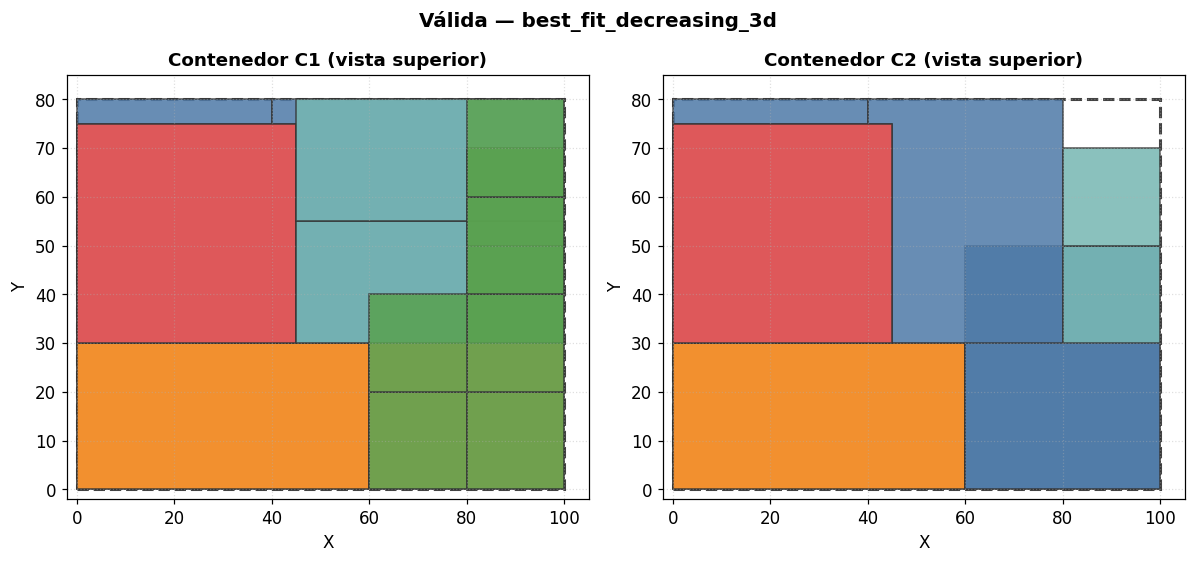

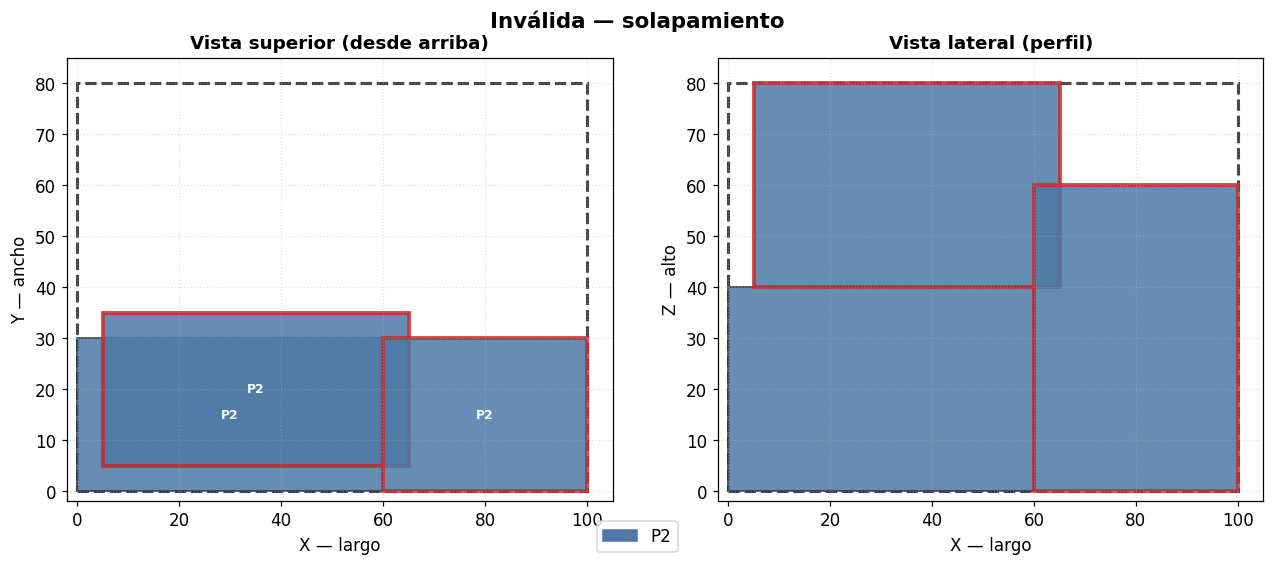

In [5]:
from packing_services.domain.models import Container, PackingSolution, ExecutionMetadata, SolutionStatus
from packing_services.domain.enums import ProblemType
from packing_services import SERVICE_VERSION
from packing_services.schemas.requests import ValidateRequest

containers = [Container(**c) for c in instance['containers']]
meta = ExecutionMetadata(algorithm='validator', algorithm_family='validator', service_version=SERVICE_VERSION)
sol_ok = PackingSolution(status=SolutionStatus.SUCCESS, problem_type=ProblemType.THREE_D_BPP,
    algorithm_name='best_fit_decreasing_3d', packed_items=solution.packed_items,
    validation_report=valid_resp.validation_report, execution_metadata=meta)
fig = viz.plot_all_container_views(sol_ok, containers, title_prefix='Válida')
if fig: plt.show()
overlap_ids = set()
for v in invalid_resp.validation_report.violations: overlap_ids.update(v.item_ids)
sol_bad = PackingSolution(status=SolutionStatus.SUCCESS, problem_type=ProblemType.THREE_D_BPP,
    algorithm_name='manual-bad', packed_items=ValidateRequest(**invalid_data).packed_items,
    validation_report=invalid_resp.validation_report, execution_metadata=meta)
fig = viz.plot_container_views(sol_bad, containers[0], container_id=containers[0].id,
    title='Inválida — solapamiento', highlight_items=overlap_ids)
plt.show()


**Siguiente:** `05_container_loading.ipynb`
